此代码用来测试不同几何形貌的储层的CQ和MC

In [1]:
import os
import torch 
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import tqdm as tqdm
import pickle

from pathlib import Path

CANDIDATES = [
    Path(r"C:\Users\tom\Desktop\Repository"),
    Path(r"C:\Users\Chen\Desktop\Repository"),
]
searchpaths = [p for p in CANDIDATES if p.exists()]

#tuple of repos
repos = ('machine_learning_library',)

import sys
import os
# In Jupyter notebooks, __file__ is not defined. Use the current working directory instead.
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import repo_tools
repo_tools.repos_path_finder(searchpaths, repos)
from spnc import spnc_anisotropy
import spnc_ml as ml
from deterministic_mask import fixed_seed_mask, max_sequences_mask

from single_node_res import single_node_reservoir
import ridge_regression as RR
from linear_layer import *
from mask import binary_mask
from utility import *
from NARMA10 import NARMA10
from datasets.load_TI46_digits import *
import datasets.load_TI46 as TI46
from sklearn.metrics import classification_report
from formal_Parameter_Dynamics_Preformance import *

from Morphology_Research.Reservoirs_morphology_creator import MorphologyConfig, ReservoirMorphologyManager
from Morphology_Research.Reservoirs_morphology_evaluation import *

In [ ]:
# 需要ReservoirParams
params_bestMC = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=200, beta_prime=	50.0,
        params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 200}
    )

# 需要config
config_random = MorphologyConfig(
    morph_type='random',
    beta_range=(48, 50),
    n_instances=3,
    random_seed=1234
)

config_gradient = MorphologyConfig(
    morph_type='gradient',
    beta_range=(48, 50),
    n_instances=3,
    random_seed=1234
)   

# 设置weights
weights = [1/3, 1/3, 1/3]

# 测试下是否能够跑的通
MC = evaluate_heterogeneous_MC(params_bestMC, config_random, weights)

print('MC random:', MC)

MC_gradient = evaluate_heterogeneous_MC(params_bestMC, config_gradient, weights)

print('MC gradient:', MC_gradient)

# 作为对比，使用均匀储层
config_uniform = MorphologyConfig(
    morph_type='uniform'
)

MC_uniform = evaluate_heterogeneous_MC(params_bestMC, config_uniform, weights)

print('MC uniform:', MC_uniform)






=== 开始评估储层MC ===
储层配置类型: random
储层参数 - h: 0.4, m0: 0.008, Nvirt: 200
beta_prime: 50.0
信号长度: 550
测试信号种子: 1234
使用异质储层计算
生成的deltabeta_list: [-1.6169610992422154, -0.7557824579203363, -1.124544521985771]
deltabeta_list长度: 3
使用的权重: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
权重长度: 3
temp_params: {'beta_prime': 50.0, 'beta_ref': 50.0}
res_params: {'m0': 0.008, 'h': 0.4, 'deltabeta_list': [-1.6169610992422154, -0.7557824579203363, -1.124544521985771]}
开始运行异质储层...
计算MC...
计算得到的MC值: 5.812409752245643
=== MC评估完成 ===

MC random: {'MC': np.float64(5.812409752245643)}

=== 开始评估储层MC ===
储层配置类型: gradient
储层参数 - h: 0.4, m0: 0.008, Nvirt: 200
beta_prime: 50.0
信号长度: 550
测试信号种子: 1234
使用异质储层计算
生成的deltabeta_list: [-2.0, -1.0, 0.0]
deltabeta_list长度: 3
使用的权重: [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
权重长度: 3
temp_params: {'beta_prime': 50.0, 'beta_ref': 50.0}
res_params: {'m0': 0.008, 'h': 0.4, 'deltabeta_list': [-2.0, -1.0, 0.0]}
开始运行异质储层...
计算MC...
计算得到的MC值: 5.607823707

In [ ]:
# 调查‘子目标1’，具体细节见notion-储层形貌与计算指标相关性

# 创建一个基准储层

# 设置param
params = ReservoirParams(
        h=0.4, m0=0.008, Nvirt=200, beta_prime=	45.0,
        params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 200}
    )

# 设置config
config = MorphologyConfig(
    morph_type='uniform'
)

# 设置weights
weights = [1/3, 1/3, 1/3]

# 测试MC作为基准
MC_uniform = evaluate_heterogeneous_MC(params, config, weights)

print('MC uniform:', MC_uniform)







=== 开始评估储层MC ===
储层配置类型: uniform
储层参数 - h: 0.4, m0: 0.008, Nvirt: 200
beta_prime: 45.0
信号长度: 550
测试信号种子: 1234
使用均质储层计算
计算MC...
计算得到的MC值: 5.830723785757934
=== MC评估完成 ===

MC uniform: {'MC': np.float64(5.830723785757934)}


In [25]:
# 下面对不同尺寸的储层进行测试

#设置循环参数
number_of_instances = np.arange(2, 21, 1)

# 创建一个列表来存储数据
result = []


# 设置param
params = ReservoirParams(
    h=0.4, m0=0.008, Nvirt=200, beta_prime=	45.0,
    params={'theta': 0.1564938388583194, 'gamma': 0.04608425844940916, 'Nvirt': 200}
)

for i in number_of_instances:
    # 设置config
    config = MorphologyConfig(
        morph_type='gradient',
        beta_range=(40, 50),
        n_instances=i,
        random_seed=1234
    )

    # 设置weights
    weights = [1/i] * i

    # 测试MC
    data = evaluate_heterogeneous_MC(params, config, weights)

    # 这个语法不正确，因为 result 是一个列表，不能用字典的方式赋值。应该用 append 添加字典元素：
    result.append({'MC': data['MC'], 'number_of_instances': i})






=== 开始评估储层MC ===
储层配置类型: gradient
储层参数 - h: 0.4, m0: 0.008, Nvirt: 200
beta_prime: 45.0
信号长度: 550
测试信号种子: 1234
使用异质储层计算
生成的deltabeta_list: [-5.0, 5.0]
deltabeta_list长度: 2
使用的权重: [np.float64(0.5), np.float64(0.5)]
权重长度: 2
temp_params: {'beta_prime': 45.0, 'beta_ref': 45.0}
res_params: {'m0': 0.008, 'h': 0.4, 'deltabeta_list': [-5.0, 5.0]}
开始运行异质储层...
计算MC...
计算得到的MC值: 5.903053412823495
=== MC评估完成 ===


=== 开始评估储层MC ===
储层配置类型: gradient
储层参数 - h: 0.4, m0: 0.008, Nvirt: 200
beta_prime: 45.0
信号长度: 550
测试信号种子: 1234
使用异质储层计算
生成的deltabeta_list: [-5.0, 0.0, 5.0]
deltabeta_list长度: 3
使用的权重: [np.float64(0.3333333333333333), np.float64(0.3333333333333333), np.float64(0.3333333333333333)]
权重长度: 3
temp_params: {'beta_prime': 45.0, 'beta_ref': 45.0}
res_params: {'m0': 0.008, 'h': 0.4, 'deltabeta_list': [-5.0, 0.0, 5.0]}
开始运行异质储层...
计算MC...
计算得到的MC值: 5.825532040619599
=== MC评估完成 ===


=== 开始评估储层MC ===
储层配置类型: gradient
储层参数 - h: 0.4, m0: 0.008, Nvirt: 200
beta_prime: 45.0
信号长度: 550
测试信号种子: 1234
使用异质储层

In [28]:
# 将数据保存为csv文件
import pandas as pd

# 将result列表转换为DataFrame
df = pd.DataFrame(result)

# 将DataFrame保存为csv文件
df.to_csv('MC_numberofinstance_2to20_gradient.csv', index=False)

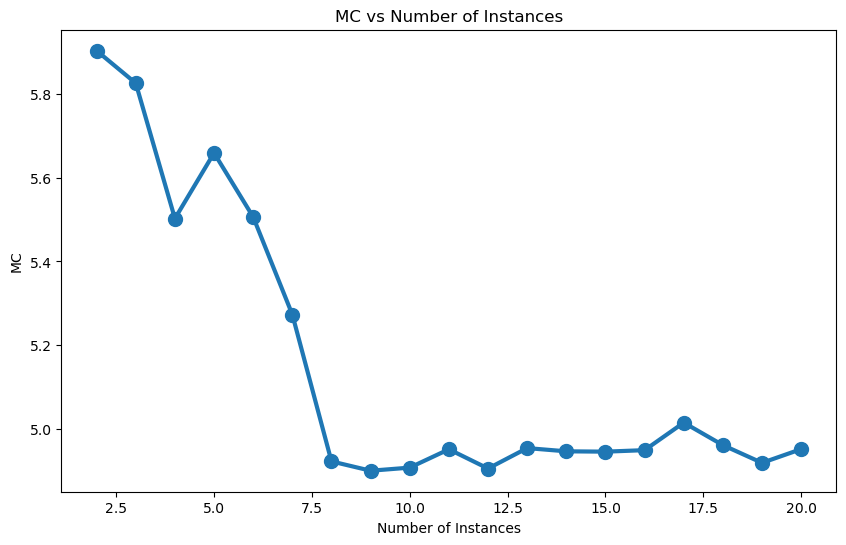

In [29]:
# 画出MC的图
plt.figure(figsize=(10, 6))
plt.plot(number_of_instances, [d['MC'] for d in result], marker='o', markersize=10, linestyle='-', linewidth=3)
plt.xlabel('Number of Instances')
plt.ylabel('MC')
plt.title('MC vs Number of Instances')
plt.show()

In [27]:
# 测试下KRandGR

result_KRandGR = []

for i in number_of_instances:
    # 设置config
    config = MorphologyConfig(
        morph_type='gradient',
        beta_range=(40, 50),
        n_instances=i,
        random_seed=1234)

    # 设置weights
    weights = [1/i] * i

    # 测试KRandGR
    data = evaluate_heterogeneous_KRandGR(params, config, weights)

    result_KRandGR.append({'KR': data['KR'], 'GR': data['GR'],'CQ': data['CQ'], 'number_of_instances': i})


# 将result_KRandGR列表转换为DataFrame
df_KRandGR = pd.DataFrame(result_KRandGR)

# 将DataFrame保存为csv文件
df_KRandGR.to_csv('KRandGR_numberofinstance_2to20_gradient.csv', index=False)









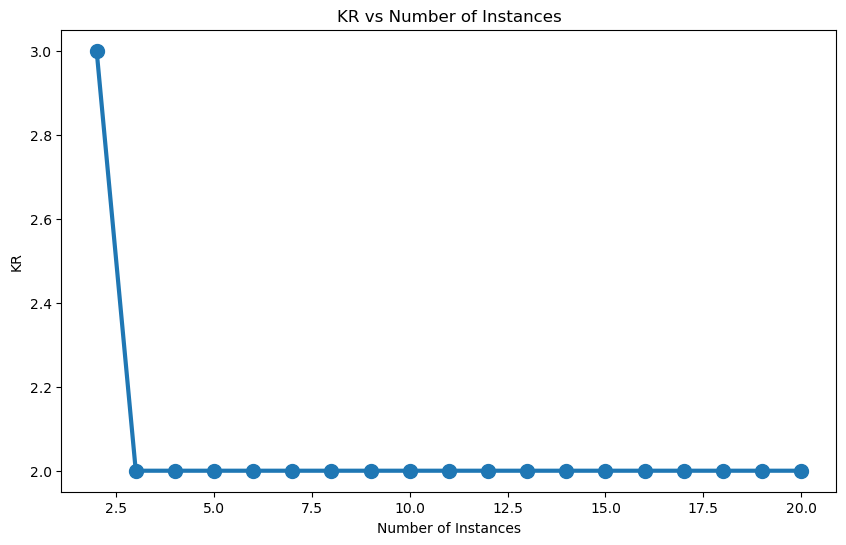

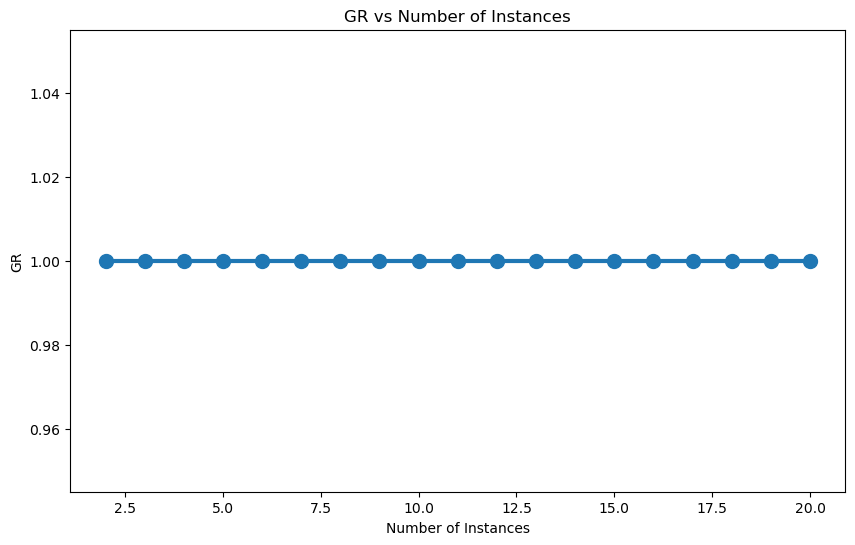

In [31]:
# 画出KR的图
plt.figure(figsize=(10, 6))
plt.plot(number_of_instances, [d['KR'] for d in result_KRandGR], marker='o', markersize=10, linestyle='-', linewidth=3)
plt.xlabel('Number of Instances')
plt.ylabel('KR')
plt.title('KR vs Number of Instances')
plt.show()

# 画出GR的图
plt.figure(figsize=(10, 6))
plt.plot(number_of_instances, [d['GR'] for d in result_KRandGR], marker='o', markersize=10, linestyle='-', linewidth=3)
plt.xlabel('Number of Instances')
plt.ylabel('GR')
plt.title('GR vs Number of Instances')
plt.show()